# Spatial surface water mass transformation on the shelf

We compute yearly maps of the surface-flux terms of the water mass transformation budget over the Antarctic continental shelf, without integrating spatially, for the dense σ2 classes (36.25–38.5 kg m⁻³). These maps are used to find where Dense Shelf Water forms and how that changes (`03_prepare_dsw_densities_and_periods`, Figures 4–6 and 10–12).

In [1]:
import sys
import warnings

import xarray as xr
import xbudget
import xwmb
import CM4Xutils

sys.path.insert(0, "../src")
from paths import outputdir
from cm4x import cm4x_budget_files, open_cm4x_budget, cm4x_acs_region

output = outputdir("Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr")
budget_yaml = "MOM6_AABW_updated.yaml"  # xbudget definition of the mass budget terms

sigma2_range = slice(36.25, 38.5)  # dense classes kept
southern_rows = slice(None, 50)  # yh rows covering the shelf
selection = {"sigma2_l_target": sigma2_range, "yh": southern_rows}

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# 8 nodes (36 cores, 160 GB each) for the xwmb budgets over 50 five-year files
cluster = SLURMCluster(cores=36, processes=6, memory="160GB", walltime="08:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=8)
cluster.wait_for_workers(2)
client = Client(cluster)
client

<Client: 'tcp://10.151.1.98:38317' processes=6 threads=36, memory=149.04 GiB>

## Budget terms

In [3]:
surface_budget_terms = [
    "boundary_fluxes", "surface_exchange_flux", "bottom_flux", "frazil_ice",
    "surface_ocean_flux_advective_negative_rhs",
    "surface_ocean_flux_advective_negative_rhs_heat", "surface_ocean_flux_advective_negative_rhs_salt",
    "surface_exchange_flux_heat", "surface_exchange_flux_salt", "frazil_ice_heat", "bottom_flux_heat",
]

# individual surface fluxes from decomposing surface_exchange_flux
decomp_budget_terms = [
    "surface_exchange_flux_advective_evaporation_salt",
    "surface_exchange_flux_advective_rain_and_ice_salt",
    "surface_exchange_flux_advective_snow_salt",
    "surface_exchange_flux_advective_rivers_salt",
    "surface_exchange_flux_advective_icebergs_salt",
    "surface_exchange_flux_advective_virtual_precip_restoring_salt",
    "surface_exchange_flux_advective_sea_ice_salt",
    "surface_exchange_flux_nonadvective_basal_salt",
    "surface_exchange_flux_nonadvective_longwave_heat",
    "surface_exchange_flux_nonadvective_shortwave_heat",
    "surface_exchange_flux_nonadvective_sensible_heat",
    "surface_exchange_flux_nonadvective_latent_heat",
    "surface_exchange_flux_advective_mass_transfer_heat",
]


def split_boundary_fluxes(wmt):
    """Heat and salt contributions to the boundary fluxes."""
    wmt["boundary_fluxes_heat"] = (
        wmt["surface_ocean_flux_advective_negative_rhs_heat"] + wmt["surface_exchange_flux_heat"]
        + wmt["frazil_ice_heat"] + wmt["bottom_flux_heat"]
    )
    wmt["boundary_fluxes_salt"] = wmt["surface_ocean_flux_advective_negative_rhs_salt"] + wmt["surface_exchange_flux_salt"]
    wmt["surface_boundary_fluxes_salt"] = 1 * wmt["boundary_fluxes_salt"]
    wmt["surface_boundary_fluxes_heat"] = wmt["boundary_fluxes_heat"] - wmt["bottom_flux_heat"]
    return wmt


def yearly_maps(wmb, terms):
    """Yearly-mean, spatially resolved budget terms on the dense classes."""
    wmb.mass_budget("sigma2", greater_than=True, bins=None, integrate=False, along_section=False)
    wmt = wmb.wmt[terms].sel(selection).rename({"sigma2_l_target": "sigma2_l"})
    return wmt.groupby("time.year").mean("time")


def lazy_maps(files):
    """Yearly-mean surface-flux maps and their decomposition for consecutive 5-year files, as one lazy dataset."""
    ds = open_cm4x_budget(files).fillna(0.0).chunk({"sigma2_l": -1, "sigma2_i": -1})
    grid = CM4Xutils.ds_to_grid(ds)
    region = cm4x_acs_region(ds, grid)

    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=FutureWarning)
        budgets_dict = xbudget.load_yaml(budget_yaml)
        xbudget.collect_budgets(grid, budgets_dict)

        wmb = xwmb.WaterMassBudget(grid, budgets_dict, region=region)
        wmt = split_boundary_fluxes(yearly_maps(wmb, surface_budget_terms))

        wmb_decomp = xwmb.WaterMassBudget(
            grid, budgets_dict, region=region,
            decompose=["surface_exchange_flux", "nonadvective", "advective"],
        )
        wmt_decomp = yearly_maps(wmb_decomp, decomp_budget_terms)

    return xr.merge([wmt_decomp, wmt])

## Yearly-mean maps, computed in batches of files

Each batch of 5-year files is opened as one dataset; the budget is built on it once and computed into memory.

In [4]:
batch_size = 10  # 5-year files computed together in one dask graph; set to len(files) to compute everything at once
files = cm4x_budget_files(first_year=1850)
batches = [files[i:i + batch_size] for i in range(0, len(files), batch_size)]

wmts = []
for batch in batches:
    print(batch[0].split("/")[-1], "...", batch[-1].split("/")[-1])
    result = lazy_maps(batch).compute()
    assert not (result["boundary_fluxes"] == 0).all(["sigma2_l", "yh", "xh"]).any(), "all-zero years: check how the files were combined"
    wmts.append(result)

wmts = xr.concat(wmts, dim="year")

CM4Xp125_budgets_sigma2_1850-1854.zarr ... CM4Xp125_budgets_sigma2_1895-1899.zarr
Inferring Z grid coordinate: density `sigma2`
CM4Xp125_budgets_sigma2_1900-1904.zarr ... CM4Xp125_budgets_sigma2_1945-1949.zarr
Inferring Z grid coordinate: density `sigma2`
CM4Xp125_budgets_sigma2_1950-1954.zarr ... CM4Xp125_budgets_sigma2_1995-1999.zarr
Inferring Z grid coordinate: density `sigma2`
CM4Xp125_budgets_sigma2_2000-2004.zarr ... CM4Xp125_budgets_sigma2_2045-2049.zarr
Inferring Z grid coordinate: density `sigma2`
CM4Xp125_budgets_sigma2_2050-2054.zarr ... CM4Xp125_budgets_sigma2_2095-2099.zarr
Inferring Z grid coordinate: density `sigma2`


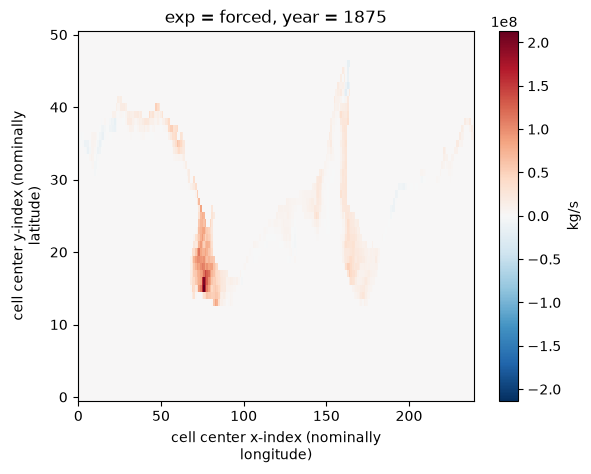

In [10]:
wmts["boundary_fluxes_heat"].isel(year = 25, exp = 0).sum("sigma2_l").plot(cbar_kwargs = {"label":"kg/s"})

In [11]:
print(f"{wmts.nbytes / 1024**3:.2f} GB")
wmts.to_zarr(output, mode="w")

45.96 GB


/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
